In [1]:
%%HTML
<script src="require.js"></script>

HTML(
    '<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/'
    'jquery.min.js"></script>'
    "<script>"
    "code_show=true;"
    "function code_toggle(){"
    "if(code_show){"
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();"
    "}else{"
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();"
    "}"
    "code_show=!code_show;"
    "}"
    "$(document).ready(code_toggle);"
    "</script>"
    '<form action="javascript:code_toggle()">'
    '<input type="submit" value="Click here to toggle on/off the raw code.">'
    "</form>"
)

In [20]:
# Standard Library Imports
import os
import glob
import gzip
import re
from pathlib import Path
from functools import reduce
from typing import List, Dict, Tuple

# Third-Party Libraries: Pandas, NumPy, Matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PySpark Core
from pyspark.sql import SparkSession
from pyspark.sql import Window
from pyspark.sql.types import (
    StructType, StructField, StringType,
    IntegerType, DoubleType, DateType
)

# PySpark SQL Functions
from pyspark.sql.functions import (
    col, lit, expr, udf, when, to_date, date_format,
    split, explode, regexp_replace, regexp_extract, input_file_name,
    round as spark_round,
    mean as _mean,
    sum as spark_sum,
    avg, row_number, desc
)

from pyspark.sql import SparkSession
from pyspark.sql.functions import lit
import os
from matplotlib.lines import Line2D

from IPython.display import display, Markdown

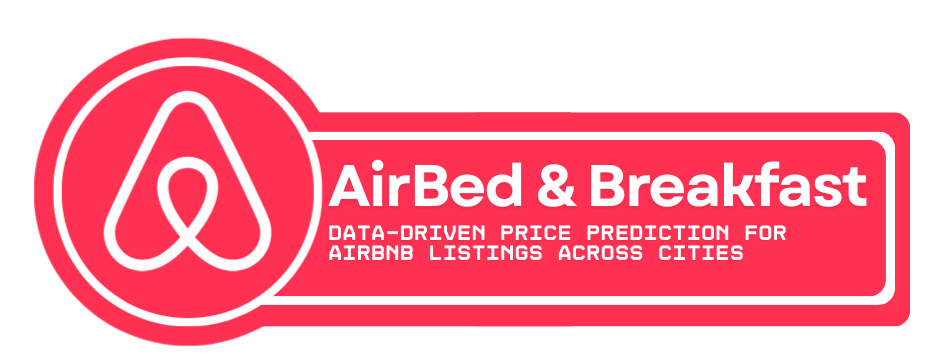

<a id='ExecSum'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">
I. Abstract
</h1>


<a id='Introduction'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">II. Introduction</h1>

The rapid expansion of short‑term rental platforms has reshaped urban accommodation markets and created a large and diverse supply of rental properties. At the same time, predicting listing prices remains challenging because prices depend on complex interactions among factors such as geographic location, property characteristics, host type, and temporal demand fluctuations. In particular, Airbnb’s distinctive model accommodates a broad spectrum of hosts, which ranges from non‑professional individuals to traditional establishments, resulting in a nuanced pricing system that poses challenges for prediction. 

The problem to be solved is, **"How can listing prices across multiple cities be accurately predicted given the heterogeneous nature of hosts and property attributes on Airbnb?"**

This problem matters because accurate price prediction can benefit both hosts, by helping them set competitive and profitable rates, and guests, by improving transparency and affordability. Moreover, understanding the factors that drive price variation can inform platform strategy, guide investment decisions, and enhance user experience.

To address this problem, this study focuses on three core objectives:
1. Combine and preprocess listing data across multiple cities to create a clean, unified dataset suitable for analysis.
2 Perform exploratory data analysis to examine how listing prices vary with respect to time, location, and listing characteristics.
3. Develop and evaluate predictive models to estimate listing prices, followed by interpretation of feature importances to identify the key drivers of price variation.

By systematically analyzing listing data and building predictive models, this study aims to provide a data-driven framework for accurate price estimation and insights into the most influential listing attributes across urban markets.

<a id='Methodology'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">III. Methodology</h1>

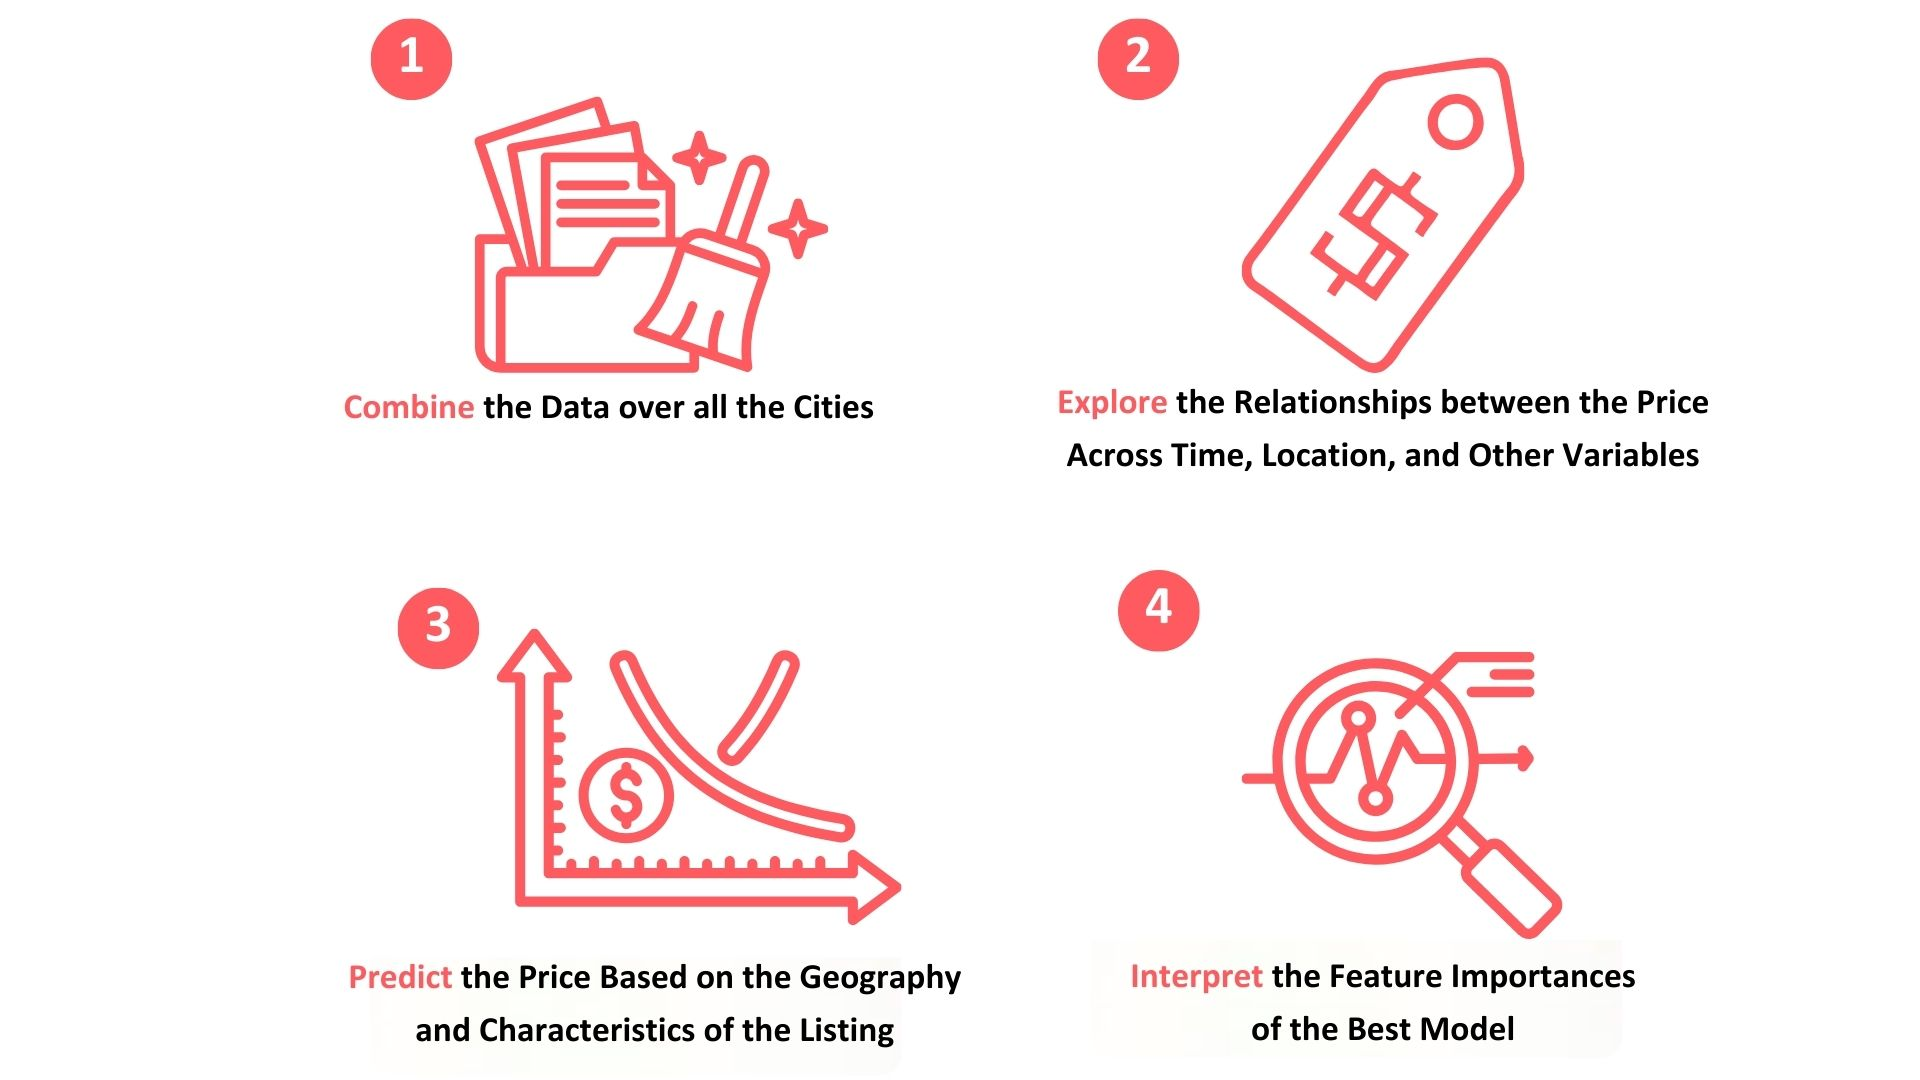
**Figure 1.** Methodology Overview

*3.1 Combine and Preprocess the Data Across All Cities*

The listing data from all cities was collected and merged into a single dataset. Relevant columns such as price, location, number of reviews, minimum nights, and room type were checked for null values and inconsistencies. Necessary preprocessing steps, including type conversions and handling missing values, were applied to ensure the dataset was ready for exploratory and predictive analysis.

*3.2 Perform Exploratory Data Analysis (EDA) to Examine Price Patterns Across Time, Location, and Listing Characteristics*

The EDA focused on understanding how listing prices vary with respect to time, geographic location, and other listing characteristics. Price trends over the years were visualized, and differences across cities and neighborhoods were analyzed using summary statistics and plots. Additionally, relationships between price and listing features such as number of reviews, minimum nights, and room type were explored to identify potential predictive variables.

*3.3 Build Predictive Models to Estimate Listing Prices Based on Geography and Characteristics*

Predictive modeling was conducted using features including geographic coordinates, room type, minimum nights, and number of reviews. Multiple regression and tree-based models were evaluated, with hyperparameter tuning applied to improve predictive performance. The models were trained on a portion of the dataset and tested on a held-out set to assess generalization.

*3.4 Interpret the Feature Importances of the Best Model*

Once the best-performing model was identified, feature importance analysis was conducted to determine which variables had the strongest influence on listing prices. Insights from this analysis were used to understand key drivers of price variation and to provide actionable interpretations for stakeholders, such as highlighting the most impactful geographic and listing characteristics.


<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">IV. Data Collection </h1>

<h2 style="color:#00A699">A. Data Source</h2>

The team utilized the InsideAirBnB dataset, which is publicly available through the ‘jojie-collected’ repository in the `/mnt/data/public` directory maintained by the Asian institute of Management. 

The datasets, located at `/mnt/data/public/insideairbnb/data.insideairbnb.com/`included several cities and we utilized all. Their data is spread across multiple CSV files, which are large and separated by dates. 

<h2 style="color:#00A699">B. Data Collection </h2>

The Airbnb data in this workflow is organized in a hierarchical folder structure where each state contains multiple cities, and within each city, data is further split by year. Each year's data is stored in its own folder, and within that folder, there is a CSV file `visualisations/listings.csv` containing the listings for that year. This structure reflects how Airbnb periodically snapshots listing data over time, resulting in multiple, large CSV files rather than a single consolidated dataset. To work with the data programmatically, the code iterates through each state and city, identifies the folders corresponding to years at or after 2024, and reads the CSV files into separate DataFrames. These per-year DataFrames for each city are then combined using unionByName into a single DataFrame for that city. This approach allows handling the temporal separation and large file sizes systematically, ensuring that all relevant data is aggregated without overwhelming memory by attempting to load everything at once.

<h2 style="color:#00A699">C. Data Description </h2>

These are the original columns that the dataset had before it was preprocessed as shown in table 1.

| Feature                        | Description                                                             | Data Type       |
| ------------------------------ | ----------------------------------------------------------------------- | --------------- |
| id                             | Unique identifier for each listing                                      | Integer/String  |
| name                           | Name/title of the listing                                               | String          |
| host_id                        | Unique identifier of the host                                           | Integer         |
| host_name                      | Name of the host                                                        | String          |
| neighbourhood_group            | Higher-level grouping of the neighborhood (often city borough/district) | String/Nullable |
| neighbourhood                  | Neighborhood or area code of the listing                                | String/Integer  |
| latitude                       | Latitude coordinate of the listing                                      | Float           |
| longitude                      | Longitude coordinate of the listing                                     | Float           |
| room_type                      | Type of room offered (Entire home/apt, Private room, Shared room)       | String          |
| price                          | Price per night in USD                                                  | Float           |
| minimum_nights                 | Minimum number of nights required for booking                           | Integer         |
| number_of_reviews              | Total number of reviews received                                        | Integer         |
| last_review                    | Date of the last review                                                 | Date/String     |
| reviews_per_month              | Average number of reviews per month                                     | Float/Nullable  |
| calculated_host_listings_count | Total number of listings the host has                                   | Integer         |
| availability_365               | Number of days listing is available in a year (0–365)                   | Integer         |
| number_of_reviews_ltm          | Number of reviews in the last twelve months                             | Integer         |
| license                        | License or permit information (if applicable)                           | String/Nullable |
| city                           | City in which the listing is located                                    | String          |
    
**Table 1.** Original Data Dictionary 

The dataset was filtered by dropping non-essential columns such as identifiers, host names, licenses, and general review statistics, keeping only features relevant for analysis. After this, the cleaned DataFrame retained rows with the remaining 10 columns describing location, room, price, host activity, and availability as shown in table 2. The total number of rows in the cleaned DataFrame was calculated to show the absolute count of listings, and dropna() was applied to count rows with complete data, giving the number of usable listings. Overall, our new dataset has 396532 data points. Finally, the proportion of usable data relative to the total was computed to justify data quality and ensure sufficient coverage for analysis.
                                                                                                                                                                                                                       
| Feature                        | Description                                                       | Data Type      |
| ------------------------------ | ----------------------------------------------------------------- | -------------- |
| neighbourhood                  | Neighborhood or area code of the listing                          | String/Integer |
| latitude                       | Latitude coordinate of the listing                                | Float          |
| longitude                      | Longitude coordinate of the listing                               | Float          |
| room_type                      | Type of room offered (Entire home/apt, Private room, Shared room) | String         |
| price                          | Price per night in USD                                            | Float          |
| minimum_nights                 | Minimum number of nights required for booking                     | Integer        |
| calculated_host_listings_count | Total number of listings the host has                             | Integer        |
| availability_365               | Number of days listing is available in a year (0–365)             | Integer        |
| number_of_reviews_ltm          | Number of reviews in the last twelve months                       | Integer        |
| city                           | City in which the listing is located                              | String         |

**Table 2.** Updated Data Dictionary 


Read the data for all the cities in the U.S. We also use this schema to ensure the correct data types when loading the csv files to the Spark dataframe. An example dataset in Table 3 in the Pandas format is included below for ease of readability; however, all analyses and processing are still performed using Spark.

In [3]:
# Set the schema
listing_schema = StructType(
    [
        StructField("id", StringType(), True),
        StructField("name", StringType(), True),
        StructField("host_id", StringType(), True),
        StructField("host_name", StringType(), True),
        StructField("neighbourhood_group", StringType(), True),
        StructField("neighbourhood", StringType(), True),
        StructField("latitude", DoubleType(), True),
        StructField("longitude", DoubleType(), True),
        StructField("room_type", StringType(), True),
        StructField("price", DoubleType(), True),
        StructField("minimum_nights", IntegerType(), True),
        StructField("number_of_reviews", IntegerType(), True),
        StructField("last_review", DateType(), True),
        StructField("reviews_per_month", DoubleType(), True),
        StructField("calculated_host_listings_count", IntegerType(), True),
        StructField("availability_365", IntegerType(), True),
        StructField("number_of_reviews_ltm", IntegerType(), True),
        StructField("license", StringType(), True),
    ]
)

In [4]:
base_dir = "/mnt/data/public/insideairbnb/data.insideairbnb.com/united-states"
states = os.listdir(base_dir)
state_cities = {
    state: [city for city in os.listdir(os.path.join(base_dir, state))]
    for state in states
}

In [5]:
spark = SparkSession.builder.appName("Airbnb").getOrCreate()

city_dfs = {}
start_year = 2015

for state, cities in state_cities.items():
    for city in cities:

        #print(state, city)

        df_data_list = []
        city_base_dir = os.path.join(base_dir, state, city)

        # Filter folders that start with a valid year
        year_folders = [
            f for f in os.listdir(city_base_dir)
            if f[:4].isdigit() and int(f[:4]) >= start_year
        ]

        for year_folder in sorted(year_folders):

            data_filepath = os.path.join(
                city_base_dir,
                year_folder,
                "visualisations",
                "listings.csv"
            )

            # Read csv
            df_data = spark.read.csv(
                data_filepath,
                header=True,
                schema=listing_schema
            )

            # Extract year & month from folder name
            if "-" in year_folder:
                year, month, date = year_folder.split("-")
                df_data = df_data \
                    .withColumn("year", lit(int(year))) \
                    .withColumn("month", lit(int(month))) \
                    .withColumn("date", lit(int(date)))
            else:
                df_data = df_data \
                    .withColumn("year", lit(int(year_folder))) \
                    .withColumn("month", lit(None)) \
                    .withColumn("date", lit(None))

            df_data_list.append(df_data)

        # Combine the data
        df_data_combined = df_data_list[0]
        for df in df_data_list[1:]:
            df_data_combined = df_data_combined.unionByName(df)

        city_dfs[city] = df_data_combined

        #print(f"Loaded {city} with {df_data_combined.count()} rows")

In [8]:
example_filepath = 'data/union_example.parquet'

# Combine all city DataFrames
unioned_df = None
for city, df in city_dfs.items():
    df_with_city = df.withColumn("city", lit(city))
    if unioned_df is None:
        unioned_df = df_with_city
    else:
        unioned_df = unioned_df.unionByName(df_with_city)
        
# Only create and save if the example file doesn't exist
if not os.path.exists(example_filepath):
    # Take first 5 rows
    example_df = unioned_df.limit(5)
    
    # Ensure directory exists
    os.makedirs(os.path.dirname(example_filepath), exist_ok=True)
    
    # Save the small example
    example_df.write.mode("overwrite").parquet(example_filepath)
    print(f"Saved example DataFrame → {example_filepath}")

# Read the example DataFrame from disk
example_df = spark.read.parquet(example_filepath)

# Preview
example_df.toPandas()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,year,month,date,city
0,665257,"Lovely cabin, great Asheville spot",2600734,Jack,28806,35.59078366342912,-82.591466,NaN,105,7.0,...,None,1.0,326,NaN,NaN,None,2016,4,18,asheville
1,2746729,Glamping w HOT TUB + AC!,4295819,Joanna And Josh,28806,35.5849679090387,-82.632199,NaN,125,2.0,...,None,4.0,228,NaN,NaN,None,2016,4,18,asheville
2,6919450,"Good size bedroom, private",36223353,Diana,28806,35.62659989827466,-82.637618,NaN,45,1.0,...,None,1.0,364,NaN,NaN,None,2016,4,18,asheville
3,12286328,Mixed Dorm,746673,BonPaul,28806,35.57915861434203,-82.596392,NaN,24,1.0,...,None,6.0,361,NaN,NaN,None,2016,4,18,asheville
4,156926,Mixed Dorm Bunk at BPS Hostel,746673,BonPaul,28806,35.577755335851116,-82.594996,NaN,24,1.0,...,None,6.0,353,NaN,NaN,None,2016,4,18,asheville


<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;"> V. Data Preprocessing </h1>

Only the years 2024 and 2025 were selected for the analysis. Because individual listings can appear multiple times across these datasets, the average price for each listing over the selected years was calculated to avoid duplication bias. Data from 2020 to 2023 were excluded due to distortions caused by the COVID-19 pandemic, which heavily affected travel and short-term rental demand. Data from years prior to 2020 were considered less relevant since they no longer reflect current market conditions or the most important considerations for listing owners today. In addition, there is a significant difference between the prices in 2024–2025 and those in earlier years as shown in Figure 2 because there has been a surge of prices across the different cities.

In [12]:
# Filter only 2024 and 2025
recent_df = unioned_df.filter(unioned_df.year.isin([2024, 2025]))

# Window per listing id, ordered by year/month/date descending
w = Window.partitionBy("id").orderBy(desc("year"), desc("month"), desc("date"))

# Keep only the latest row per id
core_attributes = (
    recent_df
    .withColumn("rn", row_number().over(w))
    .filter("rn = 1")
    .drop("rn")
)

# Compute avg price per id (over recent years only)
avg_price_df = recent_df.groupBy("id").agg(avg("price").alias("avg_price"))

# Join so that each id appears once, keeping core attributes
listings_with_avg_price_unique = avg_price_df.join(core_attributes, 
                                                   on="id", how="left")


<h2 style="color:#00A699">A. Deal with Null Values</h2>

We will drop `neighbourhood_group` and `license` because over 45.0% and 36.0% of listings do not have any values for these as shown in table 3. We also drop `last_review`, `reviews_per_month`, and `number_of_reviews` because these columns largely overlap with `number_of_reviews_ltm`.  By keeping only number_of_reviews_ltm, we capture both recent activity (last twelve months) and overall listing popularity, without retaining redundant review-related columns. Finally, we also dropped `id`, `name`, `host_id`, `host_name` since these are just identifiers for the listing. This preprocessing was applied only to listings from the years 2024 and 2025, which are the focus of the analysis. After these steps, 333,338 listings (84.0% of the data) remain for modeling.

In [13]:
filepath = "data/null_summary.csv"

# If the file does not exist yet, create the null summary
if not os.path.exists(filepath):
    total_rows = listings_with_avg_price_unique.count()
    
    null_counts_percentage = listings_with_avg_price_unique.select(
        [
            (
                spark_round(
                    1 - (spark_sum(
                        when(col(c).isNull(), 1).otherwise(0)
                    ) / total_rows), 2
                ) * 100
            ).alias(c)
            for c in listings_with_avg_price_unique.columns
        ]
    )
    
    null_counts_percentage.toPandas().to_csv(filepath, index=False)

# Read the null summary
null_counts_df = pd.read_csv(filepath).T
null_counts_df.columns = ["Percentage Remaining (%)"]
null_counts_df

,Percentage Remaining (%)
id,100.0
avg_price,88.0
name,100.0
host_id,100.0
host_name,99.0
neighbourhood_group,45.0
neighbourhood,99.0
latitude,100.0
longitude,99.0
room_type,100.0


**Table 3.** Data Completeness Summary for Airbnb Listings for the Years 2024 and 2025

<h2 style="color:#00A699">B. Data Filtering</h2>

The dataset was filtered by dropping identifiers, names, licenses, and general review columns, keeping only features related to location, room type, price, availability, host activity, and recent reviews. Rows with missing values were then counted to show how many complete data points remain for analysis.

In [14]:
# Columns to drop
cols_to_drop = [
    "id", "host_id", "name", "host_name", "neighbourhood_group",
    "license", "last_review", "reviews_per_month", "number_of_reviews",
]

# Keep everything else
remaining_cols = [
    c for c in listings_with_avg_price_unique.columns 
    if c not in cols_to_drop
]

# Create a cleaned DataFrame
dropped_listings_df = listings_with_avg_price_unique.select(*remaining_cols)

# Save the DataFrame if it doesn't exist yet
filepath = "data/cleaned_listings.parquet"
if not os.path.exists(filepath):
    dropped_listings_df.write.mode("overwrite").parquet(filepath)

# Read the DataFrame from a parquet
dropped_listings_df = spark.read.parquet(filepath)

# Show the absolute and relative count of the remaining data points
total_count = dropped_listings_df.count()
remaining_count = dropped_listings_df.dropna().count()
print(f"Total Count is {total_count}.")
print(
    f"Remaining Count is {remaining_count} "
    f"({round(remaining_count/total_count * 100, 0)}%)."
)

Total Count is 396532.
Remaining Count is 333338 (84.0%).


In [15]:
cleaned_listings_df = dropped_listings_df.dropna()

<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">VI. EDA </h1>

As shown in Figure 2, which plots the average monthly Airbnb price across all cities, there is a noticeable surge in prices in 2025. This observation motivates a focus on the most recent years, 2024 and 2025, as they are the most relevant for current market conditions. Earlier years were excluded due to distortions caused by the COVID-19 pandemic (2020–2023) and the reduced applicability of older data, ensuring that the analysis reflects the information most important for listing owners today.

In [16]:
csv_path = "data/city_monthly_cache.csv"
mean_path = "data/mean_monthly_cache.csv"

city_monthly = []

# if csv exists, just read
if os.path.exists(csv_path) and os.path.exists(mean_path):
    all_data = pd.read_csv(csv_path, parse_dates=["date"])
    mean_df = pd.read_csv(mean_path, parse_dates=["date"])

    # Re-create city_monthly structure
    for city in all_data["city"].unique():
        pdf = all_data[all_data["city"] == city].copy()
        city_monthly.append((city, pdf))

# if not, compute and save
else:
    all_city_frames = []  # for CSV saving

    for city, df in city_dfs.items():
        print(city)

        pdf = (
            df.groupBy("year", "month", "date")
            .avg("price")
            .orderBy("year", "month", "date")
            .toPandas()
        )

        pdf["date"] = pd.to_datetime(
            pdf["year"].astype(str) + "-"
            + pdf["month"].astype(str) + "-"
            + pdf["date"].astype(str)
        )

        pdf["city"] = city

        city_monthly.append((city, pdf))
        all_city_frames.append(pdf)

    # Combine all cities
    all_data = pd.concat(all_city_frames, ignore_index=True)

    # Compute overall mean
    mean_df = (
        all_data.groupby("date")["avg(price)"]
        .mean()
        .reset_index()
    )

    # Save both to csv
    all_data.to_csv(csv_path, index=False)
    mean_df.to_csv(mean_path, index=False)

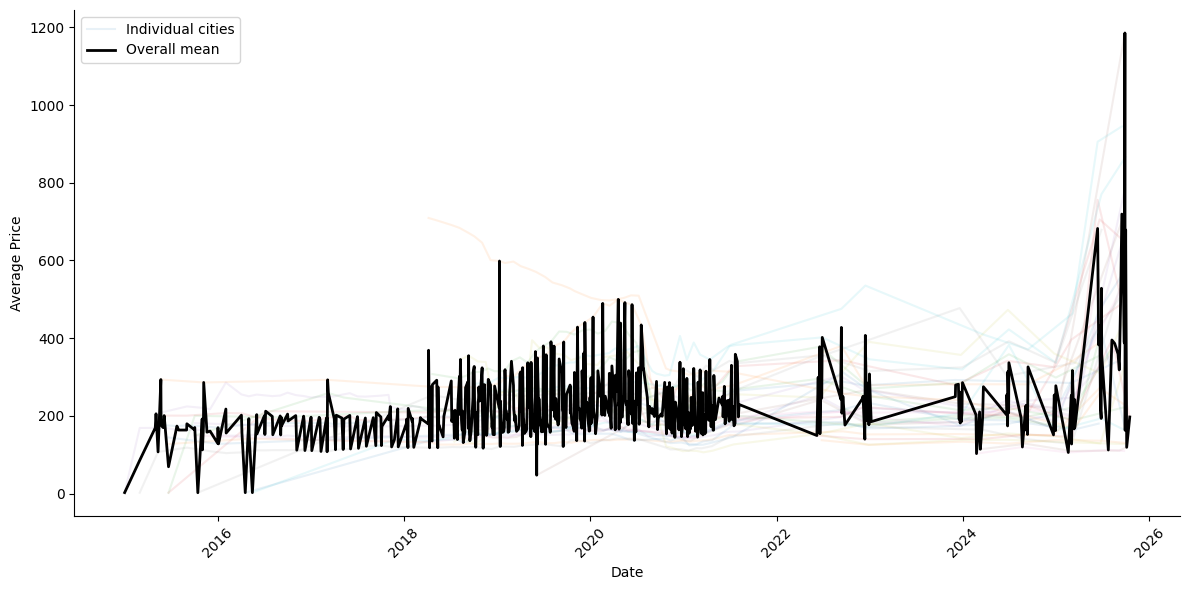

**Figure 2.** Average Monthly Airbnb Price per City with the Mean Across Cities

In [22]:
plt.figure(figsize=(12,6))

for city, pdf in city_monthly:
    plt.plot(pdf["date"], pdf["avg(price)"], alpha=0.1)

# Mean line
plt.plot(mean_df["date"], mean_df["avg(price)"], linewidth=2, color="black")

#plt.title("Average Monthly Airbnb Price per City + Overall Mean")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Add a legend
legend_elements = [
    Line2D([0], [0], label='Individual cities', alpha=0.1),
    Line2D([0], [0], label='Overall mean', linewidth=2, color="black"),
]
plt.legend(handles=legend_elements)

plt.show()

display(Markdown('**Figure 2.** Average Monthly Airbnb '
                 'Price per City with the Mean Across Cities'))

# hi bingbong, please add here the code for the eda where per city, what is its average price 

<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">VII. Modeling </h1>

The pipeline sequentially transforms categorical features (room type and city) using indexing and one-hot encoding, assembles all features into a single vector, and then fits a linear regression model to predict avg_price. The mean absolute error (MAE) of 158.55 indicates that, on average, the model's predictions deviate from the actual prices by about $158. Despite this error, the model achieves a high R² of 0.83, showing it explains most of the overall variance in listing prices across the dataset.

In [10]:
from typing import Any, Dict, Optional, Type, Union

import numpy as np
import pandas as pd


class ForecastingMetrics:
    """Class object that contains static methods for relevant
    forecasting metrics.

    Example Usage:
    --------------
    >>> from utils import ForecastingMetrics as forecast_metrics
    >>> forecast_metrics.mae(y_true, y_pred)
    """

    @staticmethod
    def mae(
        y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> np.float32:
        """Compute the mean absolute error (MAE) of a model's predictions
        against the actual (true) values.
        """
        return np.float32(np.mean(np.abs(y_true - y_pred)))

    @staticmethod
    def mse(
        y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> np.float32:
        """Compute the mean squared error (MSE) of a model's predictions
        against the actual (true) values.
        """
        return np.float32(np.mean((y_true - y_pred) ** 2))

    @staticmethod
    def rmse(
        y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> np.float32:
        """Compute the root mean squared error (RMSE) of a model's predictions
        against the actual (true) values.
        """
        return np.float32(np.sqrt(np.mean((y_true - y_pred) ** 2)))

    @staticmethod
    def mape(
        y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> np.float32:
        """Compute the mean absolute error (MAPE), in %, of a model's predictions
        against the actual (true) values.
        """
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)

        nonzero_filter = y_true != 0  # avoid division by 0
        y_true = y_true[nonzero_filter]
        y_pred = y_pred[nonzero_filter]
        return np.float32(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

    @staticmethod
    def smape(
        y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> np.float32:
        """Compute the symmetric mean absolute error (SMAPE), in %, of a
        model's predictions against the actual (true) values.
        """
        numerator = np.abs(y_true - y_pred)
        denominator = np.abs(y_true) + np.abs(y_pred)
        nonzero_filter = denominator != 0

        return np.float32(
            np.mean(numerator[nonzero_filter] / (denominator[nonzero_filter] / 2)) * 100
        )

    @staticmethod
    def direction_accuracy(
        y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> np.float32:
        """Compute the direction accuracy, in %, of your predictions against the
        actual(true) values.
        """
        true_direction = np.diff(y_true) > 0
        pred_direction = np.diff(y_pred) > 0
        return np.float32(np.mean(true_direction == pred_direction) * 100)

    # =================DELETE THESE COMMENTS AFTER EDITING===================
    # FEEL FREE TO EDIT THE METHOD BELOW TO INCLUDE YOUR OTHER METRICS
    # YOU MAY ADD MORE METRICS FOR FORECASTING IF YOU DEEM NECESSARY
    @staticmethod
    def r2(
        y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> np.float32:
        """Compute the R-squared (coefficient of determination) of the predictions."""
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return np.float32(1 - ss_res / ss_tot)

    
    @classmethod
    def compute_all_metrics(
        cls, y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]
    ) -> Dict[str, np.float32]:
        """Return a dictionary containing all of the metrics found within this
        class.
        """
        return {
            "MAE": cls.mae(y_true, y_pred),
            "MSE": cls.mse(y_true, y_pred),
            "RMSE": cls.rmse(y_true, y_pred),
            "MAPE": cls.mape(y_true, y_pred),
            "SMAPE": cls.smape(y_true, y_pred),
            "R2": cls.r2(y_true, y_pred),
            "Directional Accuracy": cls.direction_accuracy(y_true, y_pred),
        }


In [11]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Drop 'neighbourhood'
df = cleaned_listings_df.drop("neighbourhood")

# One-hot encode 'city'
indexer = StringIndexer(
    inputCol="city", outputCol="city_idx", handleInvalid="keep"
)
encoder = OneHotEncoder(inputCol="city_idx", outputCol="city_ohe")

# Assemble features
feature_cols = [
    "latitude", "longitude", "room_type", "price",
    "minimum_nights", "calculated_host_listings_count",
    "availability_365", "number_of_reviews_ltm", "city_ohe"
]

# Index room_type
room_indexer = StringIndexer(
    inputCol="room_type", outputCol="room_type_idx", handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=[c for c in feature_cols if c != "room_type"] 
              + ["room_type_idx"],
    outputCol="features"
)

# Linear Regression
lr = LinearRegression(
    featuresCol="features", labelCol="avg_price",
    maxIter=100, regParam=0.0, elasticNetParam=0.0
)

# Build pipeline
pipeline = Pipeline(
    stages=[room_indexer, indexer, encoder, assembler, lr]
)

# Train/test split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# Fit model
lr_model = pipeline.fit(train_df)

# Make predictions
preds = lr_model.transform(test_df)
preds.select("avg_price", "prediction").show(5)

# Evaluate
evaluator_r2 = RegressionEvaluator(
    labelCol="avg_price", predictionCol="prediction", metricName="r2"
)
r2 = evaluator_r2.evaluate(preds)

print(f"Linear Regression R² on test set: {r2:.2f}")

+---------+------------------+
|avg_price|        prediction|
+---------+------------------+
|      8.0| 601.3969392729518|
|      9.0| 118.3944887840994|
|     10.0|242.84734317594348|
|     13.0|16.922456018172852|
|     14.0|-1.645522227327092|
+---------+------------------+
only showing top 5 rows

Linear Regression R² on test set: 0.83


In [12]:
pred_list = [row['prediction'] 
             for row in preds.select('prediction').collect()]
pred_array = np.array(pred_list)

actual_list = [row['avg_price'] 
               for row in test_df.select('avg_price').collect()]
actual_array = np.array(actual_list)

ForecastingMetrics.compute_all_metrics(actual_array, pred_array)

{'MAE': 158.55,
 'MSE': 985060.75,
 'RMSE': 992.50226,
 'MAPE': 95.62245,
 'SMAPE': 53.988445,
 'R2': 0.8262091,
 'Directional Accuracy': 52.419464}

A Random Forest regression model was trained to predict avg_price using features including location, room type, availability, host activity, and city (one-hot encoded). The model’s mean absolute error (MAE) of about 249 indicates larger average deviations from actual prices compared to linear regression, and the R² of 0.55 shows it explains a moderate portion of the variance in listing prices. The pipeline automates the workflow by indexing and encoding categorical features, assembling all predictors into a feature vector, and fitting the Random Forest regressor, enabling end-to-end training and prediction.

In [13]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Drop 'neighbourhood'
df = cleaned_listings_df.drop("neighbourhood")

# One-hot encode 'city'
indexer = StringIndexer(
    inputCol="city", outputCol="city_idx", handleInvalid="keep"
)
encoder = OneHotEncoder(inputCol="city_idx", outputCol="city_ohe")

# Assemble features
feature_cols = [
    "latitude", "longitude", "room_type", "price",
    "minimum_nights", "calculated_host_listings_count",
    "availability_365", "number_of_reviews_ltm", "city_ohe"
]

# Index room_type
room_indexer = StringIndexer(
    inputCol="room_type", outputCol="room_type_idx", handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=[c for c in feature_cols if c != "room_type"]
              + ["room_type_idx"],
    outputCol="features"
)

# Random Forest Regressor
rf = RandomForestRegressor(
    featuresCol="features", labelCol="avg_price", seed=42
)

# Build pipeline
pipeline = Pipeline(
    stages=[room_indexer, indexer, encoder, assembler, rf]
)

# Train/test split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# Fit model
rf_model = pipeline.fit(train_df)

# Make predictions
preds = rf_model.transform(test_df)
preds.select("avg_price", "prediction").show(5)

# Evaluate
evaluator = RegressionEvaluator(
    labelCol="avg_price", predictionCol="prediction", metricName="rmse"
)
rmse = evaluator.evaluate(preds)
print(f"Random Forest RMSE on test set: {rmse:.2f}")

+---------+------------------+
|avg_price|        prediction|
+---------+------------------+
|      8.0|263.95358413020824|
|      9.0|473.37783736168274|
|     10.0| 299.1883952107976|
|     13.0| 248.8247896127858|
|     14.0|  198.230640655875|
+---------+------------------+
only showing top 5 rows

Random Forest RMSE on test set: 1599.47


In [14]:
# Convert predictions to NumPy array
pred_list = [row["prediction"] for row in 
             preds.select("prediction").collect()]
pred_array = np.array(pred_list)

# Convert actual values to NumPy array
actual_list = [row["avg_price"] for row in 
               test_df.select("avg_price").collect()]
actual_array = np.array(actual_list)

# Compute all forecasting metrics
ForecastingMetrics.compute_all_metrics(actual_array, pred_array)

{'MAE': 249.41498,
 'MSE': 2558309.2,
 'RMSE': 1599.4716,
 'MAPE': 114.42636,
 'SMAPE': 56.39011,
 'R2': 0.54864633,
 'Directional Accuracy': 55.718937}

<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;"> VIII. Hyperparameter Tuning </h1>

In [15]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

# Define the parameter grid
paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [50, 100])
             .addGrid(rf.maxDepth, [5, 10])
             .build())

# Define the evaluator
evaluator = RegressionEvaluator(
    labelCol="avg_price", 
    predictionCol="prediction", 
    metricName="rmse"
)

# Create the CrossValidator
cv = CrossValidator(
    estimator=pipeline,             # your pipeline with RF
    estimatorParamMaps=paramGrid,   # parameter grid
    evaluator=evaluator,            # evaluation metric
    numFolds=3,                     # 3-fold cross-validation
    parallelism=2                    # run multiple models in parallel
)

# Fit the CrossValidator on training data
cv_model = cv.fit(train_df)

# Make predictions with the best model
preds_cv = cv_model.transform(test_df)
preds_cv.select("avg_price", "prediction").show(5)

# Evaluate best model
rmse_cv = evaluator.evaluate(preds_cv)
print(f"Best Random Forest RMSE after CV: {rmse_cv:.2f}")

# Access best model parameters
best_rf_model = cv_model.bestModel.stages[-1]  # RF is the last stage
print("Best numTrees:", best_rf_model.getNumTrees)
print("Best maxDepth:", best_rf_model.getMaxDepth())

+---------+------------------+
|avg_price|        prediction|
+---------+------------------+
|      8.0| 73.98754358010086|
|      9.0|2780.3494752012566|
|     10.0| 151.6763296910924|
|     13.0|145.24851822632382|
|     14.0|146.78204317313694|
+---------+------------------+
only showing top 5 rows

Best Random Forest RMSE after CV: 1370.18
Best numTrees: 100
Best maxDepth: 10


In [19]:
# Convert CV predictions to NumPy array
pred_list = [row["prediction"] for row in 
             preds_cv.select("prediction").collect()]
pred_array = np.array(pred_list)

# Convert actual values to NumPy array
actual_list = [row["avg_price"] for row in 
               test_df.select("avg_price").collect()]
actual_array = np.array(actual_list)
ForecastingMetrics.compute_all_metrics(actual_array, pred_array)

{'MAE': 152.92592,
 'MSE': 1877385.5,
 'RMSE': 1370.1771,
 'MAPE': 48.259224,
 'SMAPE': 29.780779,
 'R2': 0.6687794,
 'Directional Accuracy': 53.574806}

The Linear Regression model achieved an R² of 0.83 on the test set with an MAE of 158.55, indicating a strong fit between predicted and actual prices. The initial Random Forest model without hyperparameter tuning performed worse, with an R² of 0.55 and MAE of 249.41. After hyperparameter tuning, with its best values of n_estimators of 100 and max depth of 10, the Random Forest improved to an R² of 0.67 and MAE of 152.93, showing better alignment with the true values.  However, despite the added complexity of Random Forest, its performance still remained worse compared to linear regression. This demonstrates that simpler models can sometimes perform as well as, or even better than, more complex models, and in this case our tuned Random Forest produces results that are comparable to the linear regression.The Linear Regression model achieved an R² of 0.83 on the test set with an MAE of 158.55, indicating a strong fit between predicted and actual prices. The initial Random Forest model without hyperparameter tuning performed worse, with an R² of 0.55 and MAE of 249.41. After hyperparameter tuning, with its best values of n_estimators of 100 and max depth of 10, the Random Forest improved to an R² of 0.67 and MAE of 152.93, showing better alignment with the true values.  However, despite the added complexity of Random Forest, its performance still remained worse compared to linear regression. This demonstrates that simpler models can sometimes perform as well as, or even better than, more complex models, and in this case our tuned Random Forest produces results that are comparable to the linear regression.

<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;"> IX. Limitations </h1>

<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;"> X. Recommendations </h1>

<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;"> XI. Conclusion </h1>